# Hybrid parameter learning with Refactored BayesianNetwork

=== Fitting Parameters ===
Parameter learning successful.

=== Node Predictions ===

--- Processing Node: Weather ---
Sampled values:
[[1 1 0]]

--- Processing Node: Traffic ---
Sampled values:
[[0 0 0]
 [1 1 0]]

--- Processing Node: CommuteTime ---
Sampled values:
     CommuteTime
0 0    39.670696
  1    67.137725
1 0    25.819623
  1    49.606659
2 0    22.088634
  1    94.436287

--- Processing Node: Accident ---
Sampled values:
[[0 0 0]]


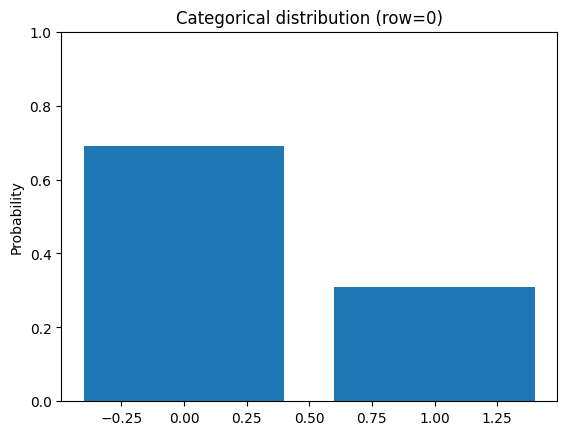

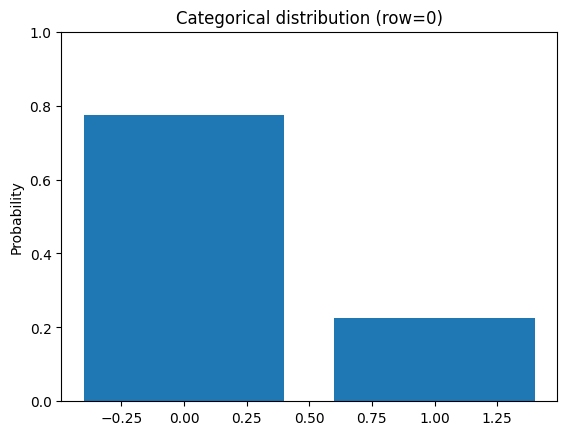

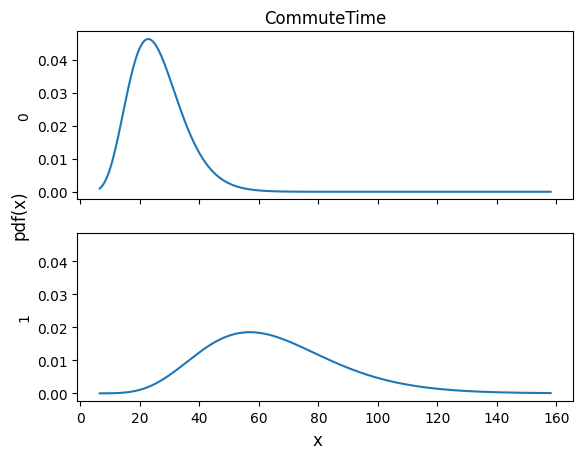

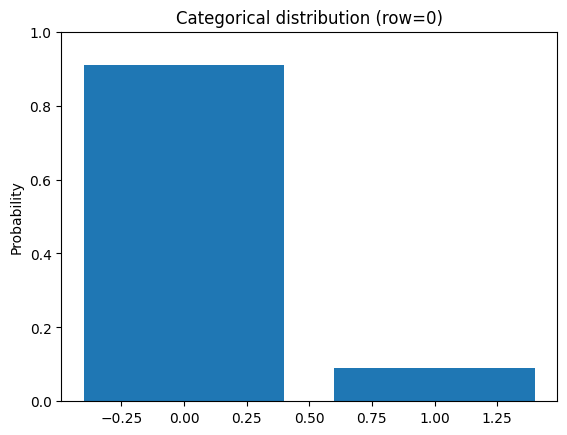

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pgmpy.factors.discrete import TabularCPD
from pgmpy.models.Refactored_BayesianNetwork import BayesianNetwork
from pgmpy.parameter_estimator import HybridEstimator
from skpro.regression.gam import GAMRegressor as GAM

# =========================================================
# 1. Wrapper Class for Continuous Models
# =========================================================
class ContinuousCPD:
    """Wrapper to make scikit-learn/skpro models compatible with pgmpy's CPD interface."""
    def __init__(self, variable, evidence, estimator):
        self.variable = variable
        self.evidence = evidence
        self.estimator = estimator

    def fit(self, data):
        # Extract features (X) and target (y) based on network structure
        X = data[self.evidence]
        y = data[self.variable]
        self.estimator.fit(X, y)
        return self

    def predict_proba(self, X):
        return self.estimator.predict_proba(X)

np.random.seed(42)
n_samples = 500
weather = np.random.choice([0, 1], p=[0.7, 0.3], size=n_samples)
accident = np.random.choice([0, 1], p=[0.9, 0.1], size=n_samples)
traffic = np.where(weather == 0,
                   np.random.choice([0, 1], p=[0.8, 0.2], size=n_samples),
                   np.random.choice([0, 1], p=[0.2, 0.8], size=n_samples))
commute_time = 20.0 + (15.0 * traffic) + (25.0 * accident) + np.random.gamma(2.0, 3.0, n_samples)

data = pd.DataFrame({'Weather': weather, 'Traffic': traffic, 'Accident': accident, 'CommuteTime': commute_time})

# =========================================================
# 2. Initialize Model and Add Empty CPDs (The Fix)
# =========================================================
model = BayesianNetwork([
    ("Weather", "Traffic"),
    ("Traffic", "CommuteTime"),
    ("Accident", "CommuteTime")
])

# Initialize TabularCPDs with dummy values (they will be overwritten during fit)
cpd_weather = TabularCPD(variable='Weather', variable_card=2, values=[[0.5], [0.5]])
cpd_accident = TabularCPD(variable='Accident', variable_card=2, values=[[0.5], [0.5]])
cpd_traffic = TabularCPD(variable='Traffic', variable_card=2, 
                         values=[[0.5, 0.5], [0.5, 0.5]], 
                         evidence=['Weather'], evidence_card=[2])

# Wrap the GAM model
cpd_commute = ContinuousCPD(
    variable='CommuteTime',
    evidence=['Traffic', 'Accident'],
    estimator=GAM(distribution="gamma")
)

# CRITICAL: Add CPDs to the model BEFORE fitting
model.add_cpds(cpd_weather, cpd_accident, cpd_traffic, cpd_commute)


# =========================================================
# 3. Parameter Learning via HybridEstimator
# =========================================================
print("=== Fitting Parameters ===")
estimator = HybridEstimator()
# Now model.cpds is populated, so fit() will successfully dispatch to each CPD
estimator.fit(model=model, data=data)
print("Parameter learning successful.")


# =========================================================
# 4. Node Predictions, Sampling, and Plotting
# =========================================================
print("\n=== Node Predictions ===")
test_scenario = pd.DataFrame({'Weather': [0, 1], 'Traffic': [0, 1], 'Accident': [0, 1]})

for node in model.nodes():
    print(f"\n--- Processing Node: {node} ---")
    
    cpd = model.get_cpds(node)
    parents = model.get_parents(node)
    
    X_test = test_scenario[parents] if parents else None 
        
    pred_dist = cpd.predict_proba(X_test)
    samples = pred_dist.sample(n_samples=3)
    print(f"Sampled values:\n{samples}")
    
    # Visualizations
    if hasattr(pred_dist, 'plot'):
        pred_dist.plot()
